# Thiranex Internship - Task 2: Customer Segmentation Project
## Unsupervised Machine Learning (K-Means & PCA) with Python (scikit-learn)

### Objective:
Segment customers based on behavioral patterns and demographics to discover distinct customer groups, analyze purchase preferences, and recommend targeted business strategies.

### Project Workflow:
1. **Exploratory Data Analysis (EDA)**
2. **Data Preprocessing & Standardization**
3. **Optimal Cluster Evaluation (Elbow Method & Silhouette Scores)**
4. **K-Means Clustering Modeling**
5. **Dimensionality Reduction via PCA (2D Projection)**
6. **Cluster Profiling & Persona Identification**
7. **Comparative Characteristic Visualizations**
8. **Actionable Marketing Insights & Recommendations**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Load Dataset

In [3]:
df = pd.read_excel('customer_segmentation.xlsx')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 19)


,CustomerID,Age,Gender,Marital_Status,Annual_Income,Education,Occupation,Region,Total_Spend,Purchase_Frequency,Average_Order_Value,Recency_Days,Customer_Tenure_Months,Return_Rate,Discount_Ratio,Preferred_Category,Preferred_Payment_Mode,Shopping_Channel,Satisfaction_Score
0,CUST-10001,24,Female,Married,43000,Bachelor's,Retired,West,3128.46,72,43.45,11,1,0.176,0.410,Beauty & Personal Care,Credit Card,Mobile App,4.7
1,CUST-10002,23,Male,Married,36400,Master's,Education,East,3702.38,26,142.40,8,7,0.122,0.506,Clothing & Apparel,Credit Card,Mobile App,4.8
2,CUST-10003,39,Male,Married,98400,Bachelor's,Retail & Trades,West,6251.65,40,156.29,30,60,0.049,0.050,Electronics,Credit Card,Mobile App,3.7
3,CUST-10004,23,Male,Single,44400,Bachelor's,Retired,West,2506.72,47,53.33,23,15,0.083,0.461,Clothing & Apparel,Credit Card,Website,4.9
4,CUST-10005,32,Female,Single,57000,High School,Retired,South,3046.06,37,82.33,10,8,0.097,0.394,Clothing & Apparel,Credit Card,Mobile App,3.8


### 2. Feature Selection & Standardization

In [4]:
features = [
    'Age', 'Annual_Income', 'Total_Spend', 'Purchase_Frequency',
    'Average_Order_Value', 'Recency_Days', 'Customer_Tenure_Months',
    'Return_Rate', 'Discount_Ratio', 'Satisfaction_Score'
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled feature matrix shape: {X_scaled.shape}")

Scaled feature matrix shape: (10000, 10)


### 3. Finding Optimal k (Elbow Method & Silhouette Score)

k=2: WCSS=63206.4, Silhouette=0.3524
k=3: WCSS=45439.7, Silhouette=0.3819
k=4: WCSS=36293.4, Silhouette=0.3646
k=5: WCSS=33051.3, Silhouette=0.2947
k=6: WCSS=30314.6, Silhouette=0.3005
k=7: WCSS=28966.0, Silhouette=0.2525
k=8: WCSS=27947.7, Silhouette=0.2371


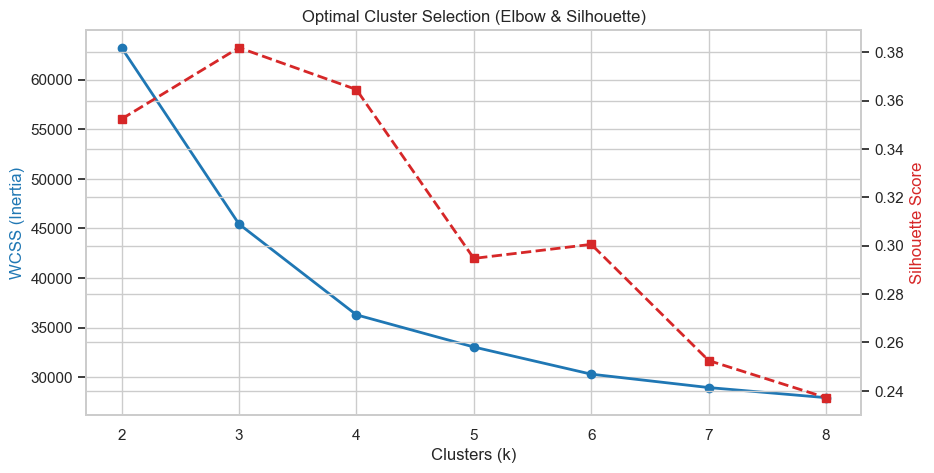

In [5]:
k_range = range(2, 9)
wcss = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k}: WCSS={km.inertia_:.1f}, Silhouette={sil:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
color = '#1f77b4'
ax1.set_xlabel('Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(list(k_range), wcss, marker='o', color=color, linewidth=2)
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(list(k_range), sil_scores, marker='s', linestyle='--', color=color, linewidth=2)
plt.title('Optimal Cluster Selection (Elbow & Silhouette)')
plt.show()

### 4. Train K-Means Clustering Model (k=5)

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
db = davies_bouldin_score(X_scaled, df['Cluster'])
print(f"Model Silhouette Score: {sil:.4f}")
print(f"Model Davies-Bouldin Index: {db:.4f}")

Model Silhouette Score: 0.2947
Model Davies-Bouldin Index: 1.3541


### 5. Principal Component Analysis (PCA) for 2D Visualization

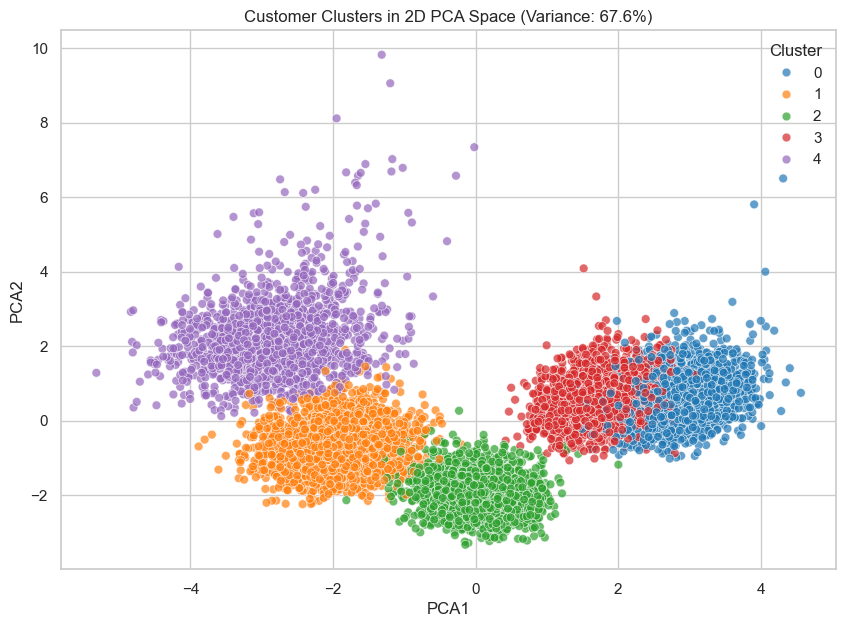

In [7]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='tab10', alpha=0.7, s=40)
plt.title(f'Customer Clusters in 2D PCA Space (Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)')
plt.show()

### 6. Cluster Profiling and Persona Mapping

In [8]:
cluster_profiles = df.groupby('Cluster')[features].mean().round(2)
display(cluster_profiles)

persona_map = {
    0: "Occasional & At-Risk Shoppers",
    1: "Loyal Family Home-Makers",
    2: "Budget Bargain Hunters",
    3: "Young Tech & Trend Seekers",
    4: "High-Value VIP Spenders"
}
df['Segment_Persona'] = df['Cluster'].map(persona_map)
df['Segment_Persona'].value_counts()

,Age,Annual_Income,Total_Spend,Purchase_Frequency,Average_Order_Value,Recency_Days,Customer_Tenure_Months,Return_Rate,Discount_Ratio,Satisfaction_Score
Cluster,,,,,,,,,,
0,41.80,116789.91,6248.67,37.69,175.69,18.27,41.21,0.05,0.12,4.58
1,36.16,34128.85,1135.82,21.89,57.13,46.61,24.29,0.16,0.72,3.70
2,24.18,48101.24,3195.45,47.77,70.32,12.39,18.14,0.11,0.38,4.19
3,48.05,78588.01,4396.15,32.46,142.83,21.71,47.28,0.06,0.27,4.49
4,38.23,52209.57,654.95,4.94,171.32,192.61,28.50,0.22,0.45,2.79


Segment_Persona
Loyal Family Home-Makers         2520
Young Tech & Trend Seekers       2118
Budget Bargain Hunters           2014
Occasional & At-Risk Shoppers    1874
High-Value VIP Spenders          1474
Name: count, dtype: int64

### 7. Demographic & Purchasing Behavior Comparisons

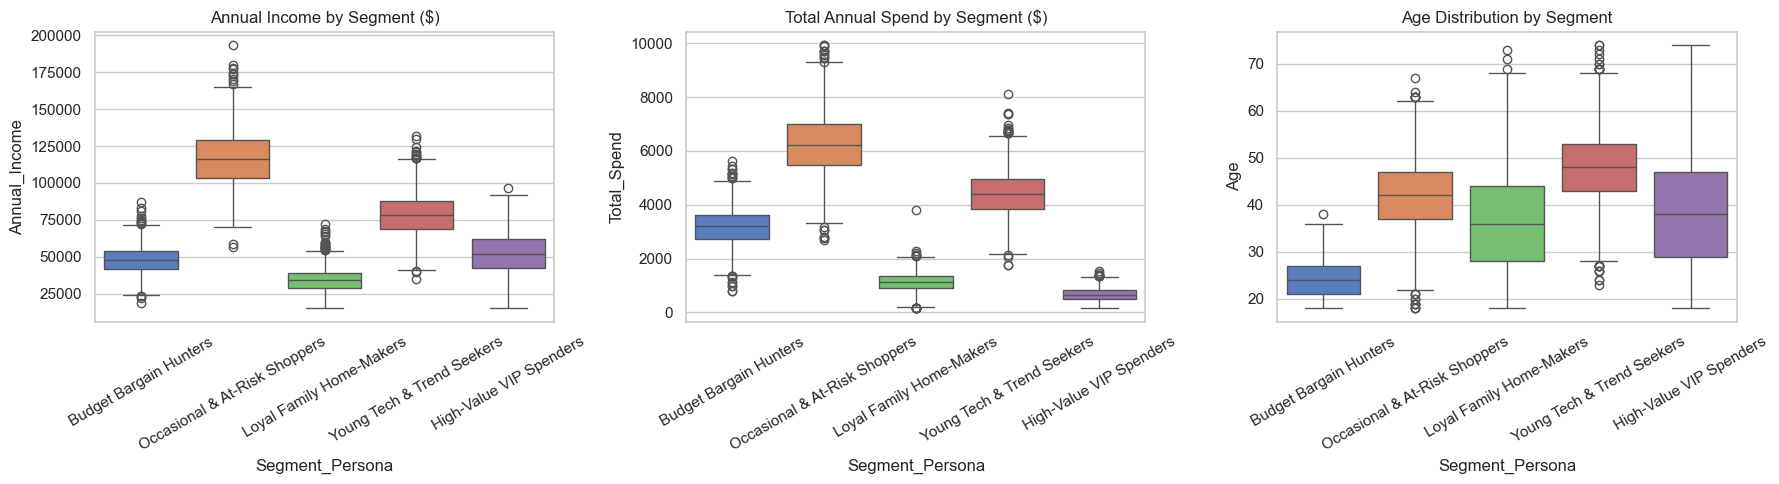

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Segment_Persona', y='Annual_Income', hue='Segment_Persona', data=df, ax=axes[0], legend=False)
axes[0].set_title('Annual Income by Segment ($)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(x='Segment_Persona', y='Total_Spend', hue='Segment_Persona', data=df, ax=axes[1], legend=False)
axes[1].set_title('Total Annual Spend by Segment ($)')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(x='Segment_Persona', y='Age', hue='Segment_Persona', data=df, ax=axes[2], legend=False)
axes[2].set_title('Age Distribution by Segment')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 8. Category and Channel Preferences

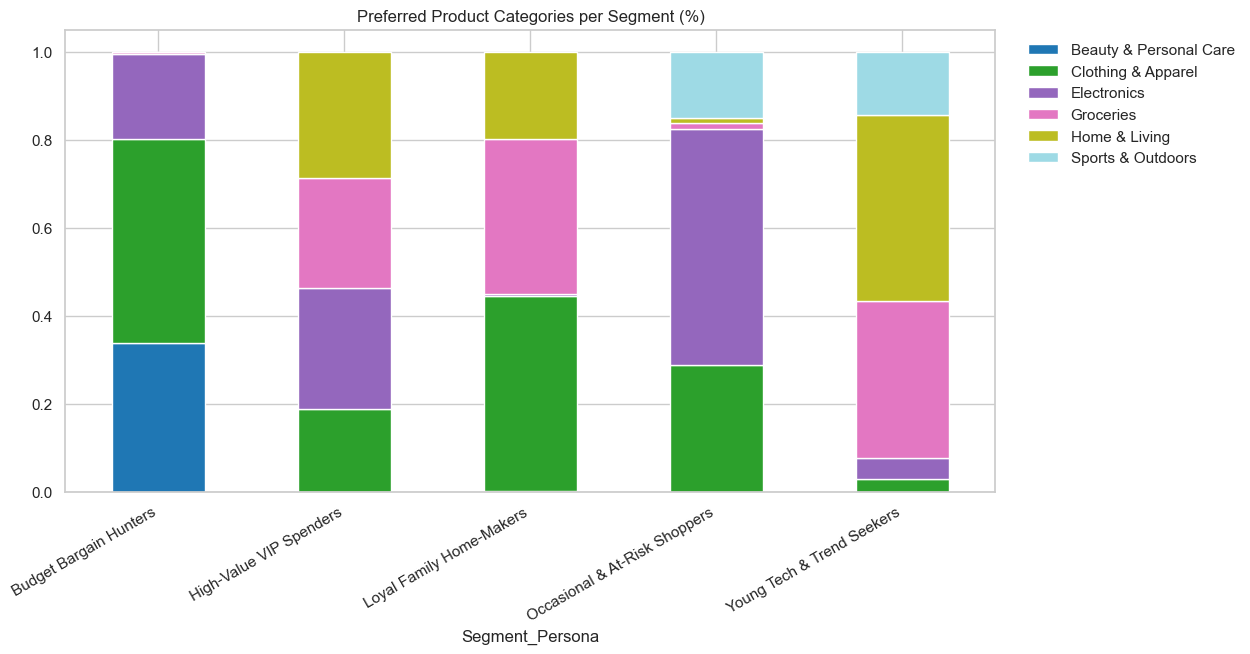

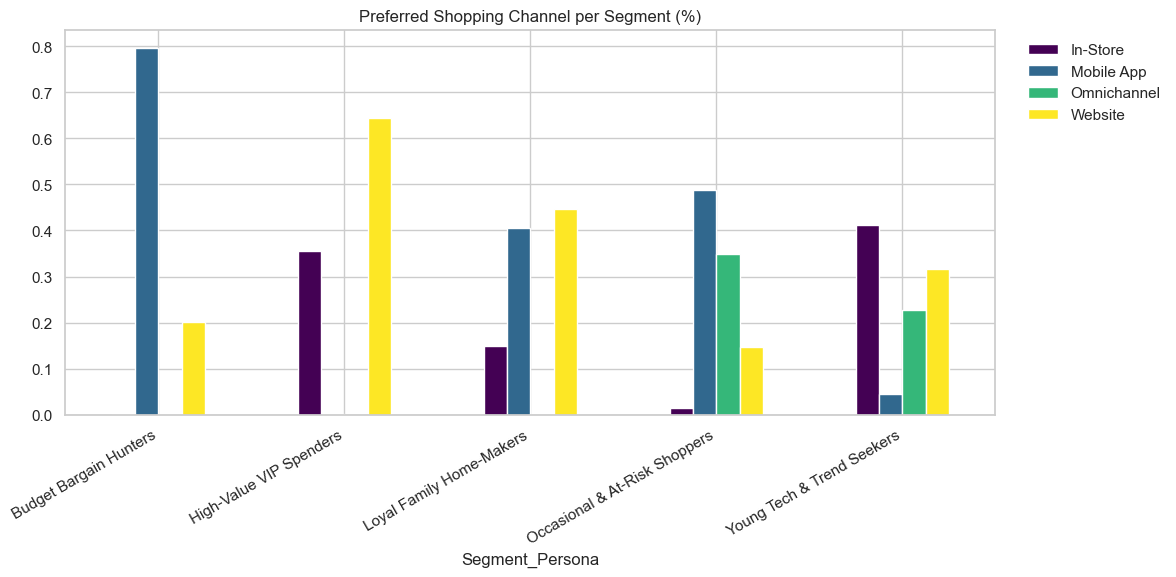

In [10]:
pd.crosstab(df['Segment_Persona'], df['Preferred_Category'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(12, 6), colormap='tab20'
)
plt.title('Preferred Product Categories per Segment (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

pd.crosstab(df['Segment_Persona'], df['Shopping_Channel'], normalize='index').plot(
    kind='bar', figsize=(12, 5), colormap='viridis'
)
plt.title('Preferred Shopping Channel per Segment (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### 9. Export Segmented Data

In [11]:
df.to_csv('segmented_customers_output.csv', index=False)
print("Exported segmented customers successfully!")

Exported segmented customers successfully!


### Task 2